<a href="https://colab.research.google.com/github/FrancescaPorcellii/Trajectory-Prediction/blob/main/Trajectory_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trajectory Prediction

This notebook demonstrates a **trajectory prediction pipeline** designed to anticipate the future movements of dynamic agents such as vehicles using past positions and scene data.

The project focuses on:

* Preprocessing raw trajectory data.
* Creating sliding windows for sequence prediction.
* Training and evaluating a deep learning model.
* Visualizing the predicted vs. ground truth trajectories.

🔗 **GitHub Repository**: [FrancescaPorcellii/Trajectory-Prediction](https://github.com/FrancescaPorcellii/Trajectory-Prediction)


## Dataset

In [ ]:
%%bash
# For v1.0 version of mini dataset
wget https://man-truckscenes.s3.eu-central-1.amazonaws.com/release/mini/man-truckscenes_metadata_v1.0-mini.zip
wget https://man-truckscenes.s3.eu-central-1.amazonaws.com/release/mini/man-truckscenes_sensordata_v1.0-mini.zip
unzip "man-truckscenes_*.zip"

Installing devkit

In [3]:
# Install devkit (if not done already)
!pip install -U "truckscenes-devkit[all]"

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 119.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 112.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.9/386.9 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.5/133.5 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 86.3 MB/s eta 0:00:00
   ━━

In [4]:
from truckscenes import TruckScenes

trucksc = TruckScenes('v1.0-mini', '/content/man-truckscenes/man-truckscenes', True)


Loading truckscenes tables for version v1.0-mini...
11 attribute,
18 calibrated_sensor,
27 category,
20090 ego_motion_cabin,
20089 ego_motion_chassis,
20116 ego_pose,
1094 instance,
400 sample,
25750 sample_annotation,
43556 sample_data,
10 scene,
18 sensor,
4 visibility,
Done loading in 1.574 seconds.
Reverse indexing ...
Done reverse indexing in 0.2 seconds.


In [5]:
!git clone https://github.com/FrancescaPorcellii/Trajectory-Prediction/

Cloning into 'Trajectory-Prediction'...
remote: Enumerating objects: 228, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 228 (delta 25), reused 7 (delta 3), pack-reused 180 (from 1)
Receiving objects: 100% (228/228), 162.18 MiB | 18.32 MiB/s, done.
Resolving deltas: 100% (126/126), done.


### Prepare dataset

In [6]:
cd Trajectory-Prediction/

/content/Trajectory-Prediction


Creating file json to create the dataset

In [7]:
from prepare_dataset import create_dataset

create_dataset(trucksc)

✅ Saved 280 windows of 10 frames with the closest vehicle moving
✅ Saved 1120 windows of 10 frames with the closest vehicle moving (augmented 3x)


## Train standard

### Creating samples without drop

In [8]:
from collections import defaultdict
import numpy as np
import json


input_len = 3
pred_len = 7
total_len = input_len + pred_len

timestamp_to_sample = {}
for sample in trucksc.sample:
    ts_sec = round(sample['timestamp'] / 1e6, 3)
    timestamp_to_sample[str(ts_sec)] = sample['token']

with open('timestamp_to_sample.json', 'w') as f:
    json.dump(timestamp_to_sample, f, indent=2)

with open('nearest_vehicle_trajectories_augmented.json') as f:
    windowed_data = json.load(f)


flat_data = []
for window in windowed_data:
    for entry in window:
        flat_data.append(entry)
with open('flat_data.json', 'w') as f:
    json.dump(flat_data, f, indent=2)

tracks = defaultdict(list)
seen = set()
metadata = {}

for entry in flat_data:
    instance_token = entry.get('instance_token')
    translation = entry.get('translation')
    timestamp = float(entry.get('timestamp'))
    ann_token = entry.get('annotation_token')

    rounded_ts = str(round(timestamp, 3))
    sample_token = timestamp_to_sample.get(rounded_ts)

    ego_translation = None
    ego_rotation = None

    if sample_token:
        sample = trucksc.get('sample', sample_token)

        sd_token_list = [v for k, v in sample['data'].items()]
        sd = None
        for sd_tok in sd_token_list:
             try:
                 sd = trucksc.get('sample_data', sd_tok)

                 if 'ego_pose_token' in sd:
                      ego_pose = trucksc.get('ego_pose', sd['ego_pose_token'])
                      ego_translation = ego_pose['translation']
                      ego_rotation = ego_pose['rotation']
                      break
             except Exception as e:

                 print(f"Error processing sample_data token {sd_tok}: {e}")
                 continue



    if ann_token is not None:
        metadata[ann_token] = {
            'translation': entry.get('translation'),
            'ego_translation': ego_translation,
            'ego_rotation': ego_rotation
        }

    if instance_token is not None and translation is not None:

      timestamps_in_track = {t for t, _, _ in tracks[instance_token]}
      if timestamp not in timestamps_in_track:
          tracks[instance_token].append((timestamp, translation, ann_token))


for token in tracks:
    tracks[token].sort(key=lambda x: x[0])

samples = []
for window in windowed_data:

    tracks_in_window = defaultdict(list)
    for entry in window:
        token = entry['instance_token']
        ts = entry['timestamp']
        translation = entry['translation']
        ann_token = entry['annotation_token']
        tracks_in_window[token].append((ts, translation, ann_token, entry.get('is_augmented', False)))

    for token in tracks_in_window:
        tracks_in_window[token].sort(key=lambda x: x[0])
        trajectory = tracks_in_window[token]
        if len(trajectory) < total_len:
            continue
        for i in range(len(trajectory) - total_len + 1):
            seq = trajectory[i:i + total_len]
            input_seq = np.stack([np.array(p[1][:2]) for p in seq[:input_len]])
            target_seq = np.stack([np.array(p[1][:2]) for p in seq[input_len:]])
            ann_tokens_window = [p[2] for p in seq]
            is_aug = any(p[3] for p in seq)

            samples.append((input_seq, target_seq, ann_tokens_window, is_aug))

print(f"✅ Generati {len(samples)} sample (input={input_len}, target={pred_len})")

with open("metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

✅ Generati 1120 sample (input=3, target=7)


### Training

In [9]:
from train import train_model
model, debug_preds = train_model(samples, num_epochs=100, batch_size=4, lr=0.001, mode = "load")

Average trajectory length: 26.6426
Mean Absolute Error (MAE): 2.3321
Accuracy percentage: 91.25%

Saved predictions: 280 / 280 (non-augmented)



## Train with drop target

### Creating samples with drop target

In [66]:
from collections import defaultdict
import numpy as np
import json


input_len = 3
pred_len = 7
total_len = input_len + pred_len

timestamp_to_sample = {}
for sample in trucksc.sample:
    ts_sec = round(sample['timestamp'] / 1e6, 3)
    timestamp_to_sample[str(ts_sec)] = sample['token']

with open('timestamp_to_sample.json', 'w') as f:
    json.dump(timestamp_to_sample, f, indent=2)

with open('nearest_vehicle_trajectories_augmented.json') as f:
    windowed_data = json.load(f)


flat_data = []
for window in windowed_data:
    for entry in window:
        flat_data.append(entry)
with open('flat_data.json', 'w') as f:
    json.dump(flat_data, f, indent=2)

tracks = defaultdict(list)
seen = set()
metadata = {}

for entry in flat_data:
    instance_token = entry.get('instance_token')
    translation = entry.get('translation')
    timestamp = float(entry.get('timestamp'))
    ann_token = entry.get('annotation_token')


    rounded_ts = str(round(timestamp, 3))
    sample_token = timestamp_to_sample.get(rounded_ts)

    ego_translation = None
    ego_rotation = None

    if sample_token:
        sample = trucksc.get('sample', sample_token)
        sd_token_list = [v for k, v in sample['data'].items()]
        sd = None
        for sd_tok in sd_token_list:
             try:
                 sd = trucksc.get('sample_data', sd_tok)

                 if 'ego_pose_token' in sd:
                      ego_pose = trucksc.get('ego_pose', sd['ego_pose_token'])
                      ego_translation = ego_pose['translation']
                      ego_rotation = ego_pose['rotation']
                      break
             except Exception as e:

                 print(f"Error processing sample_data token {sd_tok}: {e}")
                 continue



    if ann_token is not None:
        metadata[ann_token] = {
            'translation': entry.get('translation'),
            'ego_translation': ego_translation,
            'ego_rotation': ego_rotation
        }

    if instance_token is not None and translation is not None:

      timestamps_in_track = {t for t, _, _ in tracks[instance_token]}
      if timestamp not in timestamps_in_track:
          tracks[instance_token].append((timestamp, translation, ann_token))



for token in tracks:
    tracks[token].sort(key=lambda x: x[0])


FILL_VALUE = np.nan
samples = []
for window in windowed_data:

    tracks_in_window = defaultdict(list)
    for entry in window:
        token = entry['instance_token']
        ts = entry['timestamp']
        translation = entry['translation']
        ann_token = entry['annotation_token']
        tracks_in_window[token].append(
            (ts, translation, ann_token, entry.get('is_augmented', False))
        )

    for token, trajectory in tracks_in_window.items():
        trajectory.sort(key=lambda x: x[0])
        if len(trajectory) < total_len:
            continue
        for i in range(len(trajectory) - total_len + 1):
            seq = trajectory[i:i + total_len]
            drop_idx = np.random.randint(input_len, total_len)

            coords = []
            for j, p in enumerate(seq):
                xy = np.array(p[1][:2], dtype=np.float32)
                if j == drop_idx:
                    xy[:] = FILL_VALUE
                coords.append(xy)
            coords = np.stack(coords)

            input_seq   = coords[:input_len]
            target_seq  = coords[input_len:]

            mask_target = ~np.isnan(target_seq[:, 0])
            ann_window  = [p[2] for p in seq]
            is_aug      = any(p[3] for p in seq)

            samples.append((input_seq, target_seq, ann_window,
                is_aug, mask_target.tolist()))
with open("metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

### Training

In [67]:
from train import train_model
model, debug_preds = train_model(samples, num_epochs=100, batch_size=4, lr=0.001, mode = "load", drop = 'target')

Average trajectory length: 25.4585
Mean Absolute Error (MAE): 2.6498
Accuracy percentage: 89.59%

Saved predictions: 280 / 280 (non-augmented)



## Train with drop input

### Creating samples with drop input

In [100]:
from collections import defaultdict
import numpy as np
import json


input_len = 3
pred_len = 7
total_len = input_len + pred_len

timestamp_to_sample = {}
for sample in trucksc.sample:
    ts_sec = round(sample['timestamp'] / 1e6, 3)
    timestamp_to_sample[str(ts_sec)] = sample['token']

with open('timestamp_to_sample.json', 'w') as f:
    json.dump(timestamp_to_sample, f, indent=2)

with open('nearest_vehicle_trajectories_augmented.json') as f:
    windowed_data = json.load(f)


flat_data = []
for window in windowed_data:
    for entry in window:
        flat_data.append(entry)
with open('flat_data.json', 'w') as f:
    json.dump(flat_data, f, indent=2)

tracks = defaultdict(list)
seen = set()
metadata = {}

for entry in flat_data:
    instance_token = entry.get('instance_token')
    translation = entry.get('translation')
    timestamp = float(entry.get('timestamp'))
    ann_token = entry.get('annotation_token')


    rounded_ts = str(round(timestamp, 3))
    sample_token = timestamp_to_sample.get(rounded_ts)

    ego_translation = None
    ego_rotation = None

    if sample_token:
        sample = trucksc.get('sample', sample_token)

        sd_token_list = [v for k, v in sample['data'].items()]
        sd = None
        for sd_tok in sd_token_list:
             try:
                 sd = trucksc.get('sample_data', sd_tok)

                 if 'ego_pose_token' in sd:
                      ego_pose = trucksc.get('ego_pose', sd['ego_pose_token'])
                      ego_translation = ego_pose['translation']
                      ego_rotation = ego_pose['rotation']
                      break
             except Exception as e:

                 print(f"Error processing sample_data token {sd_tok}: {e}")
                 continue



    if ann_token is not None:
        metadata[ann_token] = {
            'translation': entry.get('translation'),
            'ego_translation': ego_translation,
            'ego_rotation': ego_rotation
        }

    if instance_token is not None and translation is not None:

      timestamps_in_track = {t for t, _, _ in tracks[instance_token]}
      if timestamp not in timestamps_in_track:
          tracks[instance_token].append((timestamp, translation, ann_token))


for token in tracks:
    tracks[token].sort(key=lambda x: x[0])


FILL_VALUE = np.nan

samples = []
for window in windowed_data:

    tracks_in_window = defaultdict(list)
    for entry in window:
        token = entry['instance_token']
        ts = entry['timestamp']
        translation = entry['translation']
        ann_token = entry['annotation_token']
        tracks_in_window[token].append(
            (ts, translation, ann_token, entry.get('is_augmented', False))
        )

    for token, trajectory in tracks_in_window.items():
        trajectory.sort(key=lambda x: x[0])
        if len(trajectory) < total_len:
            continue
        for i in range(len(trajectory) - total_len + 1):
            seq = trajectory[i:i + total_len]
            drop_idx = np.random.randint(0, input_len)

            coords = []
            for j, p in enumerate(seq):
                xy = np.array(p[1][:2], dtype=np.float32)
                if j == drop_idx:
                    xy[:] = FILL_VALUE
                coords.append(xy)
            coords = np.stack(coords)

            input_seq   = coords[:input_len]
            target_seq  = coords[input_len:]

            mask_target = ~np.isnan(target_seq[:, 0])
            ann_window  = [p[2] for p in seq]
            is_aug      = any(p[3] for p in seq)

            samples.append((input_seq, target_seq, ann_window,
                is_aug, mask_target.tolist()))

print(f"✅ Generati {len(samples)} sample (input={input_len}, target={pred_len})")

with open("metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

✅ Generati 1120 sample (input=3, target=7)


### Training

In [101]:
from train import train_model
model, debug_preds = train_model(samples, num_epochs=100, batch_size=4, lr=0.001, mode = "load", drop = 'input')


Average trajectory length: 26.6426
Mean Absolute Error (MAE): 3.7537
Accuracy percentage: 85.91%

Saved predictions: 280 / 280 (non-augmented)



## Visualize Results

Run only one or the other to visualize the results


In [91]:
#curved trajectory
first_ann_token = '1d7312b670b7407399f4fd6d306f21ba'

In [72]:
#straight trajectory
first_ann_token = '0845230972324963aed57016b8dac28b'

First annotation token: 1d7312b670b7407399f4fd6d306f21ba
✅ matched sample: {'input': [[nan, nan], [4.116513729095459, 9.768831253051758], [1.4776240587234497, 12.302059173583984]], 'pred': [[-4.680335521697998, 14.709888458251953], [-7.437975883483887, 18.683881759643555], [-12.259840965270996, 21.820796966552734], [-17.791152954101562, 24.505796432495117], [-22.68201446533203, 26.36292839050293], [-26.369300842285156, 26.86589813232422], [-29.58734130859375, 26.71555519104004]], 'gt': [[-1.6596174240112305, 14.76431655883789], [-5.183765888214111, 17.202238082885742], [-8.991483688354492, 19.685585021972656], [-13.08413028717041, 22.208877563476562], [-17.351669311523438, 24.533998489379883], [-21.560823440551758, 26.509902954101562], [-25.578990936279297, 28.06743621826172]], 'mask': [True, True, True, True, True, True, True], 'ann_tokens': ['1d7312b670b7407399f4fd6d306f21ba', '11a0db40433941c09df99049c12cd31c', 'df44d57ad3e841c7a4976b7527aeb0a7', '59500956564841a096711fe5ea4cd2de', 

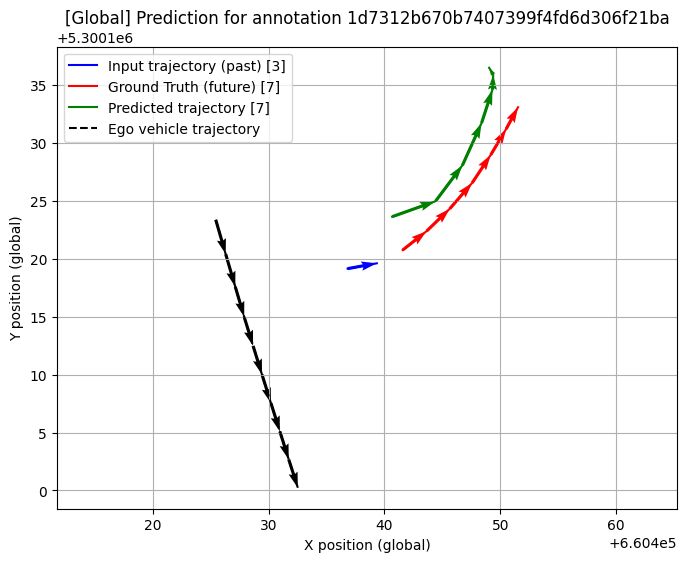

In [102]:
from data_visualization import visualize_trajectory

matched_sample, input_seq, target_s, pred_seq = visualize_trajectory(trucksc, debug_preds,first_ann_token)

Render over the image the real box and the predicted box



Box GT: label: nan, score: nan, xyz: [1.79, 1.22, 14.80], wlh: [1.75, 4.29, 1.57], rot axis: [-0.74, 0.47, -0.48], ang(degrees): -109.44, ang(rad): -1.91, vel: nan, nan, nan, name: GT, token: None
Box Prediction: label: nan, score: nan, xyz: [-0.14, 1.17, 14.34], wlh: [1.75, 4.29, 1.57], rot axis: [-0.74, 0.47, -0.48], ang(degrees): -109.44, ang(rad): -1.91, vel: nan, nan, nan, name: Prediction, token: None


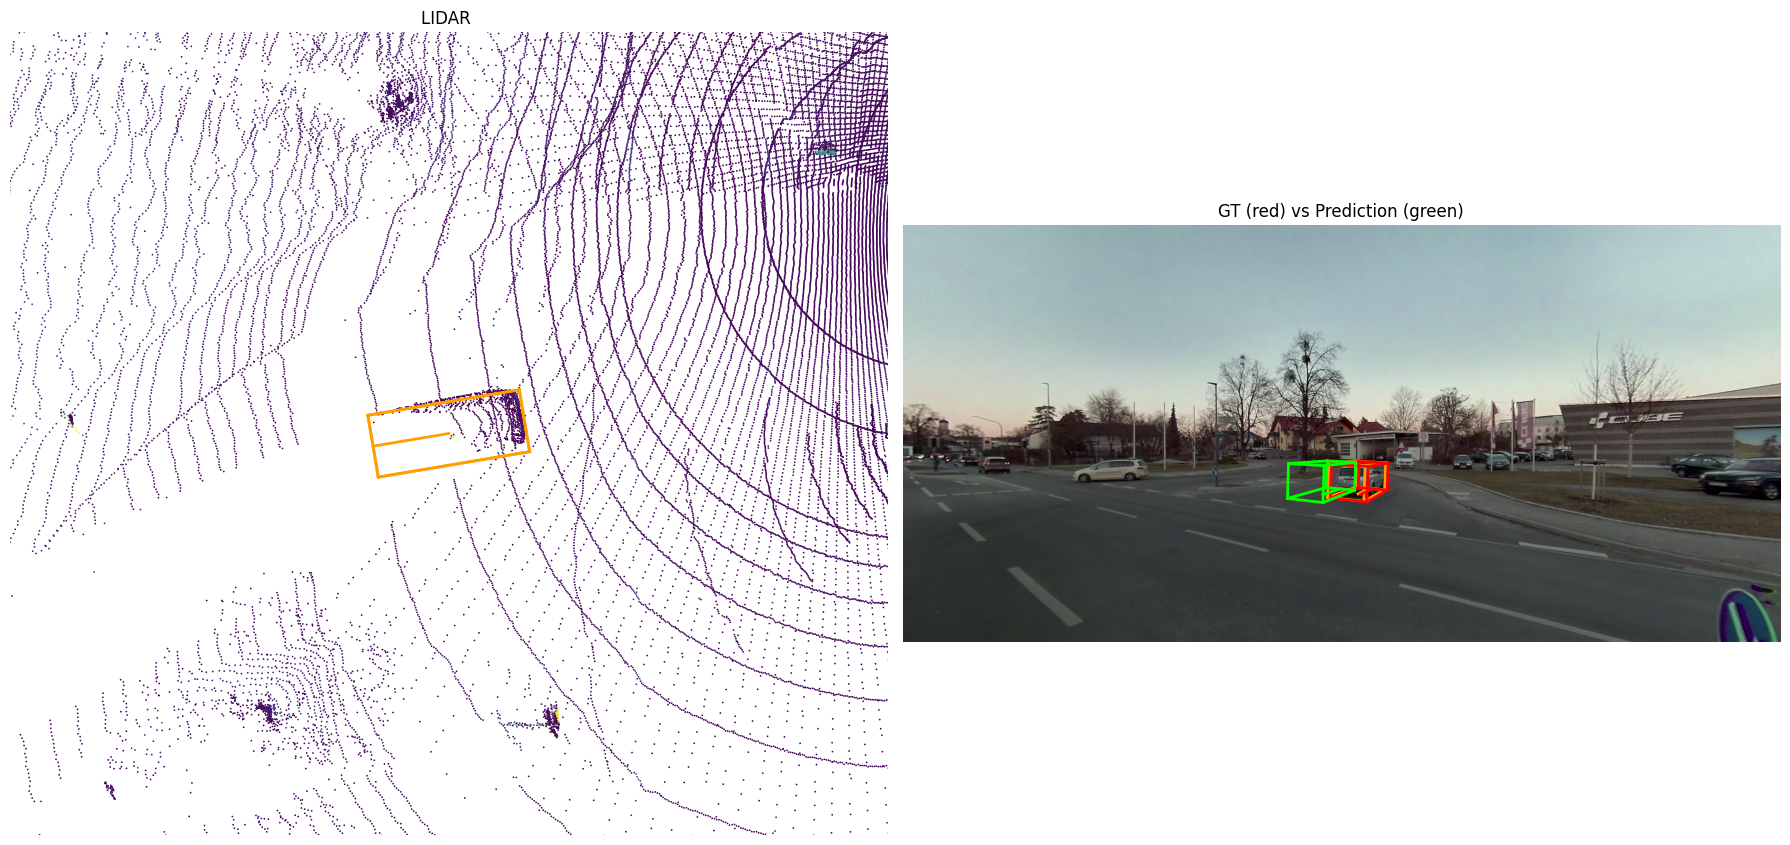

Box GT: label: nan, score: nan, xyz: [0.16, 0.97, 18.76], wlh: [1.75, 4.29, 1.57], rot axis: [-0.67, 0.52, -0.53], ang(degrees): -115.36, ang(rad): -2.01, vel: nan, nan, nan, name: GT, token: None
Box Prediction: label: nan, score: nan, xyz: [0.16, 0.97, 19.16], wlh: [1.75, 4.29, 1.57], rot axis: [-0.67, 0.52, -0.53], ang(degrees): -115.36, ang(rad): -2.01, vel: nan, nan, nan, name: Prediction, token: None


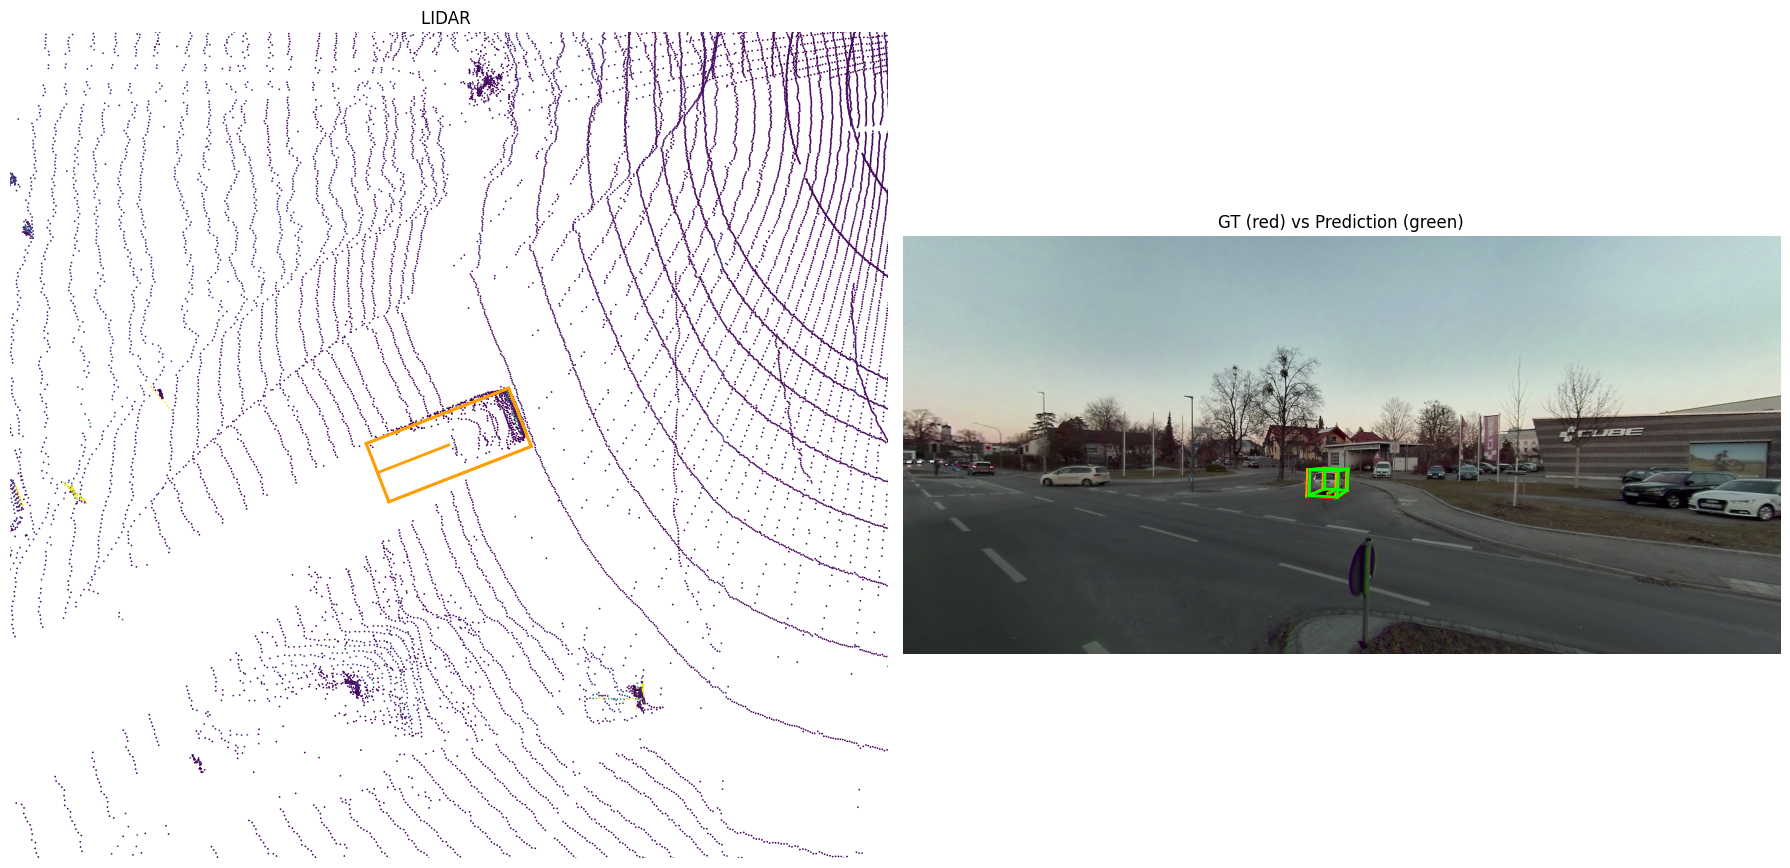

Box GT: label: nan, score: nan, xyz: [-1.67, 0.91, 22.91], wlh: [1.75, 4.29, 1.57], rot axis: [-0.64, 0.54, -0.55], ang(degrees): -117.64, ang(rad): -2.05, vel: nan, nan, nan, name: GT, token: None
Box Prediction: label: nan, score: nan, xyz: [-1.70, 0.87, 24.69], wlh: [1.75, 4.29, 1.57], rot axis: [-0.64, 0.54, -0.55], ang(degrees): -117.64, ang(rad): -2.05, vel: nan, nan, nan, name: Prediction, token: None


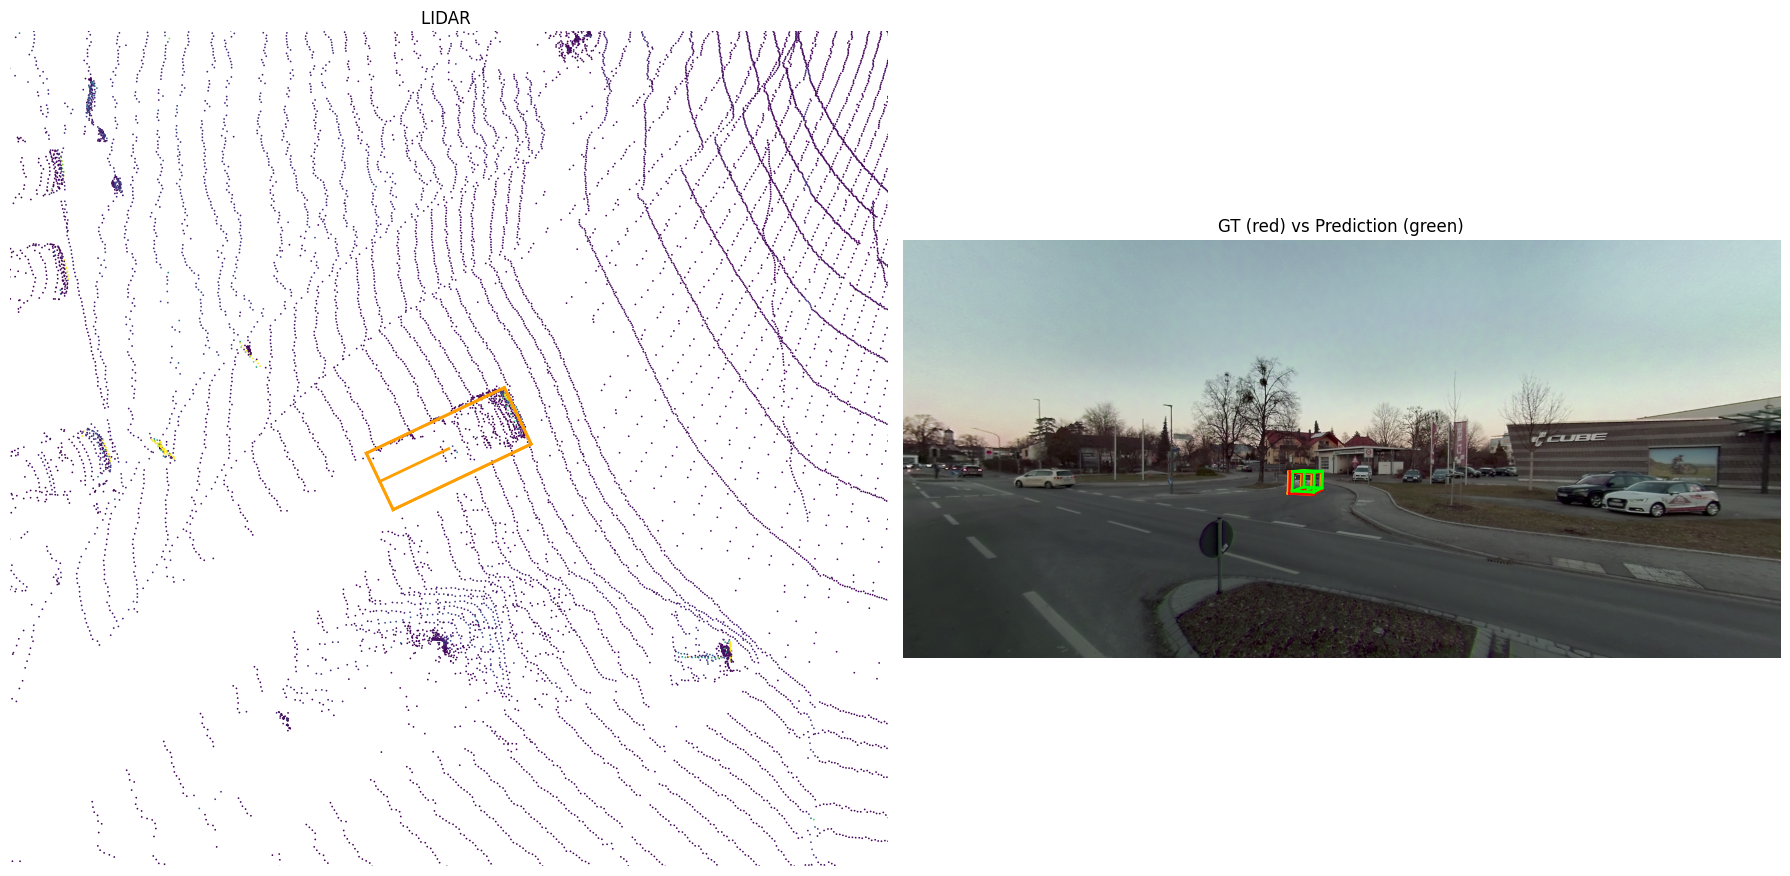

Box GT: label: nan, score: nan, xyz: [-3.73, 0.89, 27.26], wlh: [1.75, 4.29, 1.57], rot axis: [-0.61, 0.56, -0.57], ang(degrees): -120.24, ang(rad): -2.10, vel: nan, nan, nan, name: GT, token: None
Box Prediction: label: nan, score: nan, xyz: [-4.69, 0.79, 30.32], wlh: [1.75, 4.29, 1.57], rot axis: [-0.61, 0.56, -0.57], ang(degrees): -120.24, ang(rad): -2.10, vel: nan, nan, nan, name: Prediction, token: None


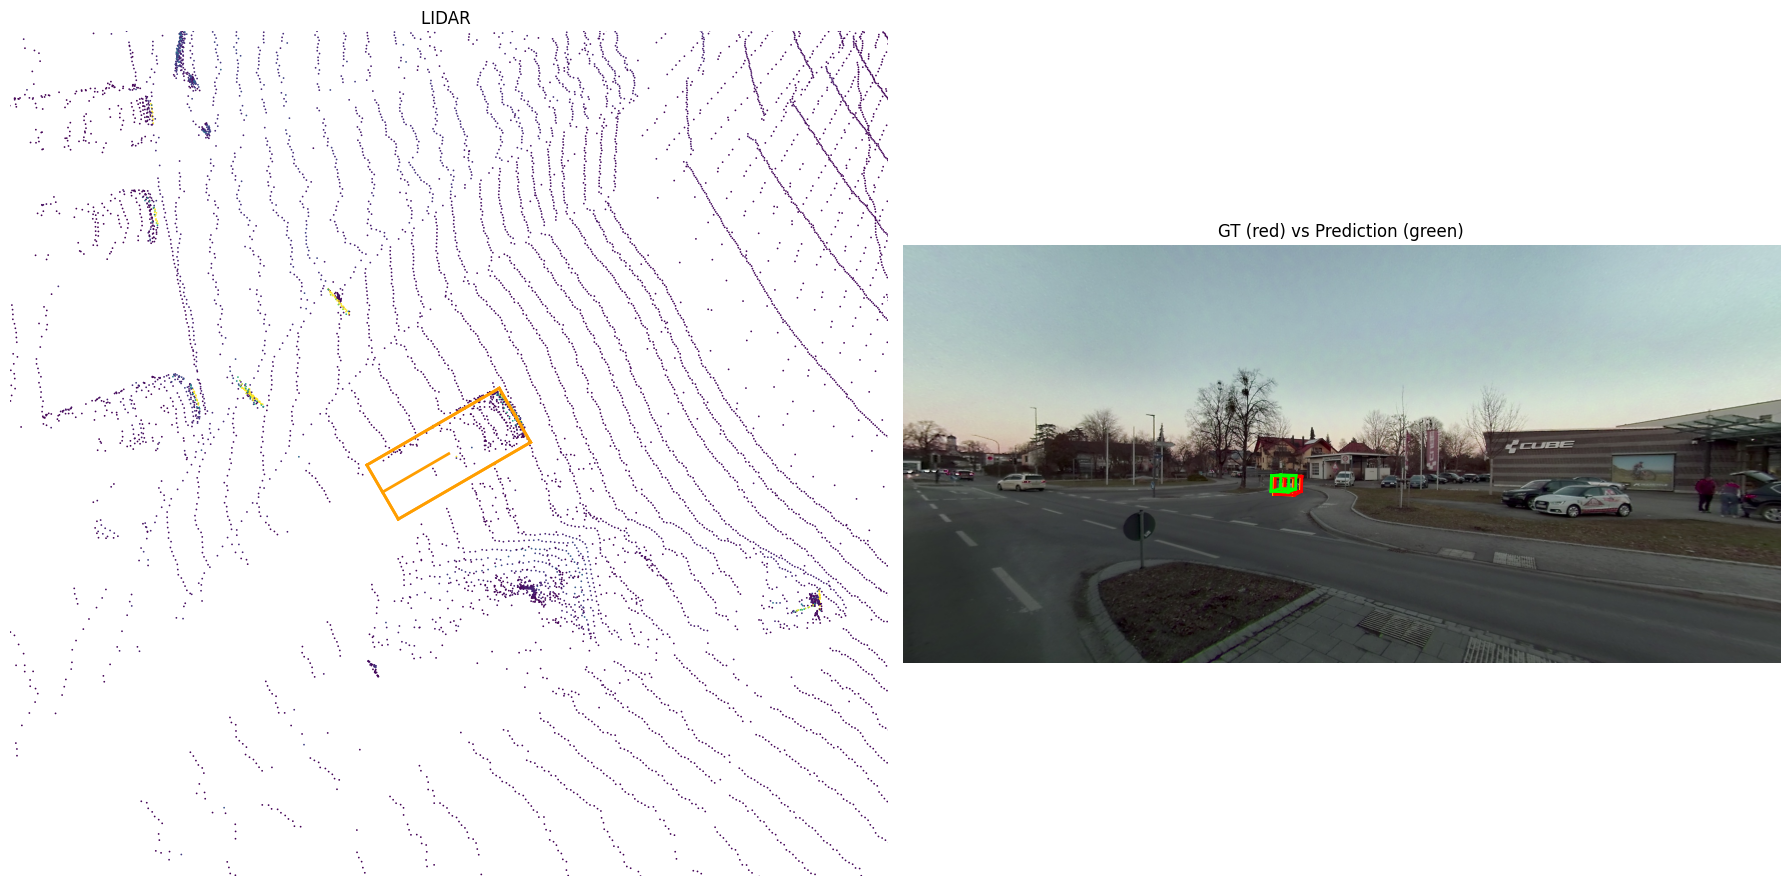

Box GT: label: nan, score: nan, xyz: [-6.04, 0.60, 31.54], wlh: [1.75, 4.29, 1.57], rot axis: [-0.55, 0.59, -0.59], ang(degrees): -125.02, ang(rad): -2.18, vel: nan, nan, nan, name: GT, token: None
Box Prediction: label: nan, score: nan, xyz: [-7.66, 0.46, 35.13], wlh: [1.75, 4.29, 1.57], rot axis: [-0.55, 0.59, -0.59], ang(degrees): -125.02, ang(rad): -2.18, vel: nan, nan, nan, name: Prediction, token: None


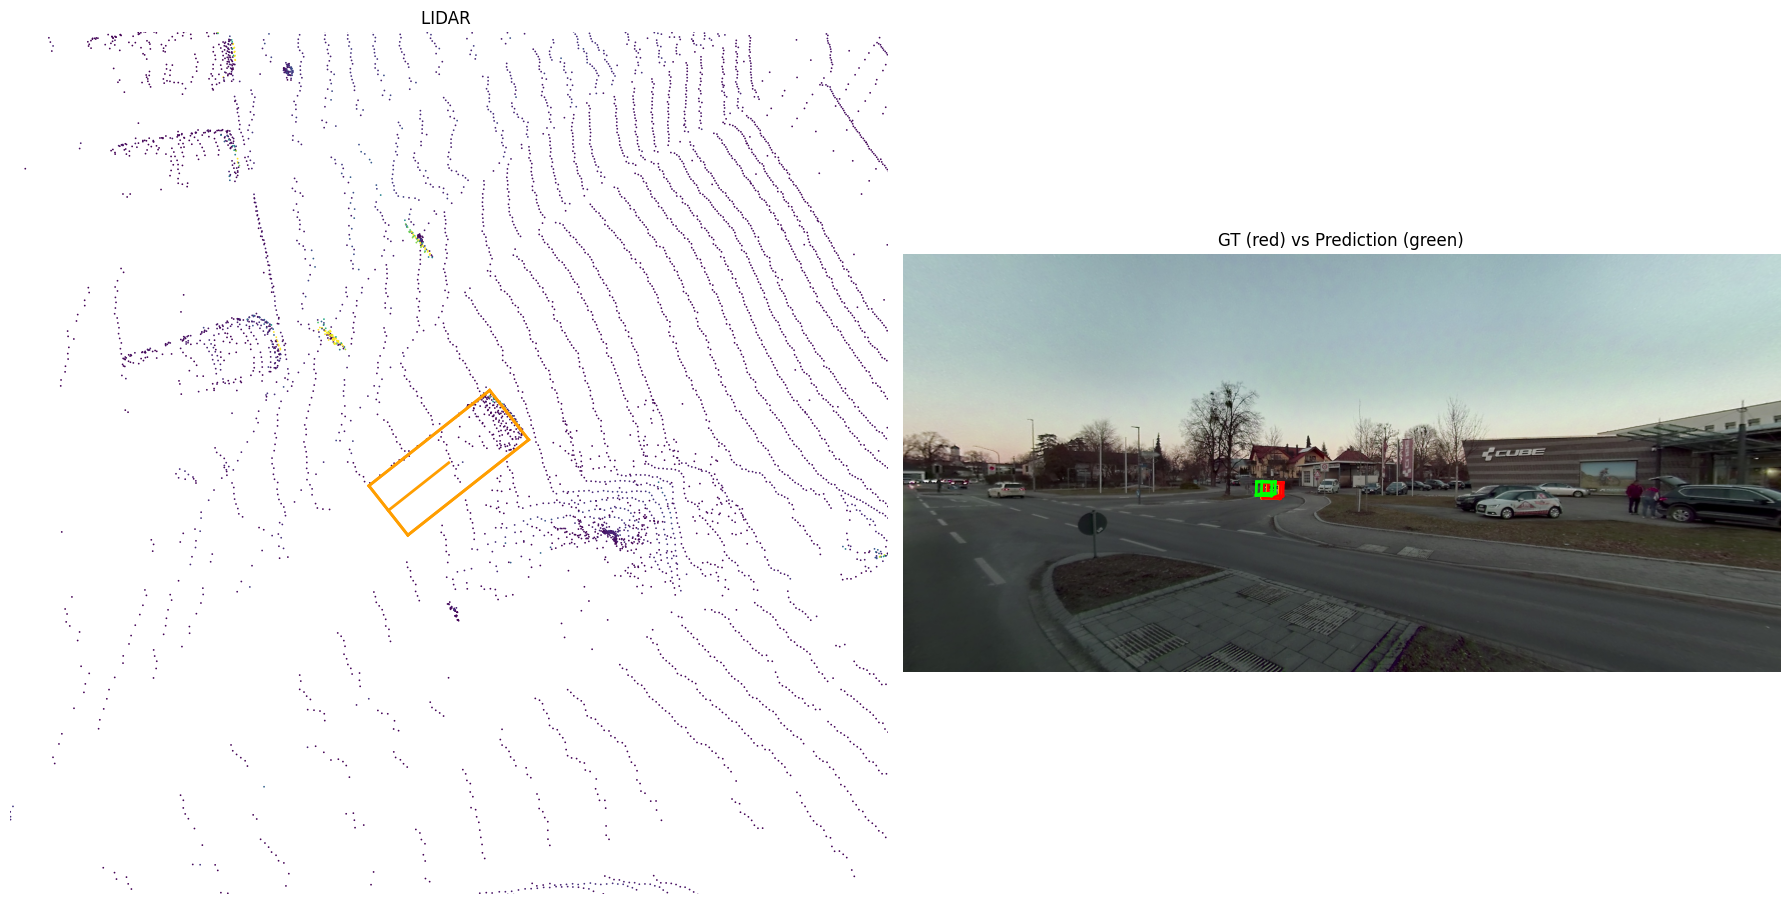

Box GT: label: nan, score: nan, xyz: [-8.47, 0.55, 35.50], wlh: [1.75, 4.29, 1.57], rot axis: [-0.55, 0.59, -0.59], ang(degrees): -125.60, ang(rad): -2.19, vel: nan, nan, nan, name: GT, token: None
Box Prediction: label: nan, score: nan, xyz: [-10.31, 0.40, 38.94], wlh: [1.75, 4.29, 1.57], rot axis: [-0.55, 0.59, -0.59], ang(degrees): -125.60, ang(rad): -2.19, vel: nan, nan, nan, name: Prediction, token: None


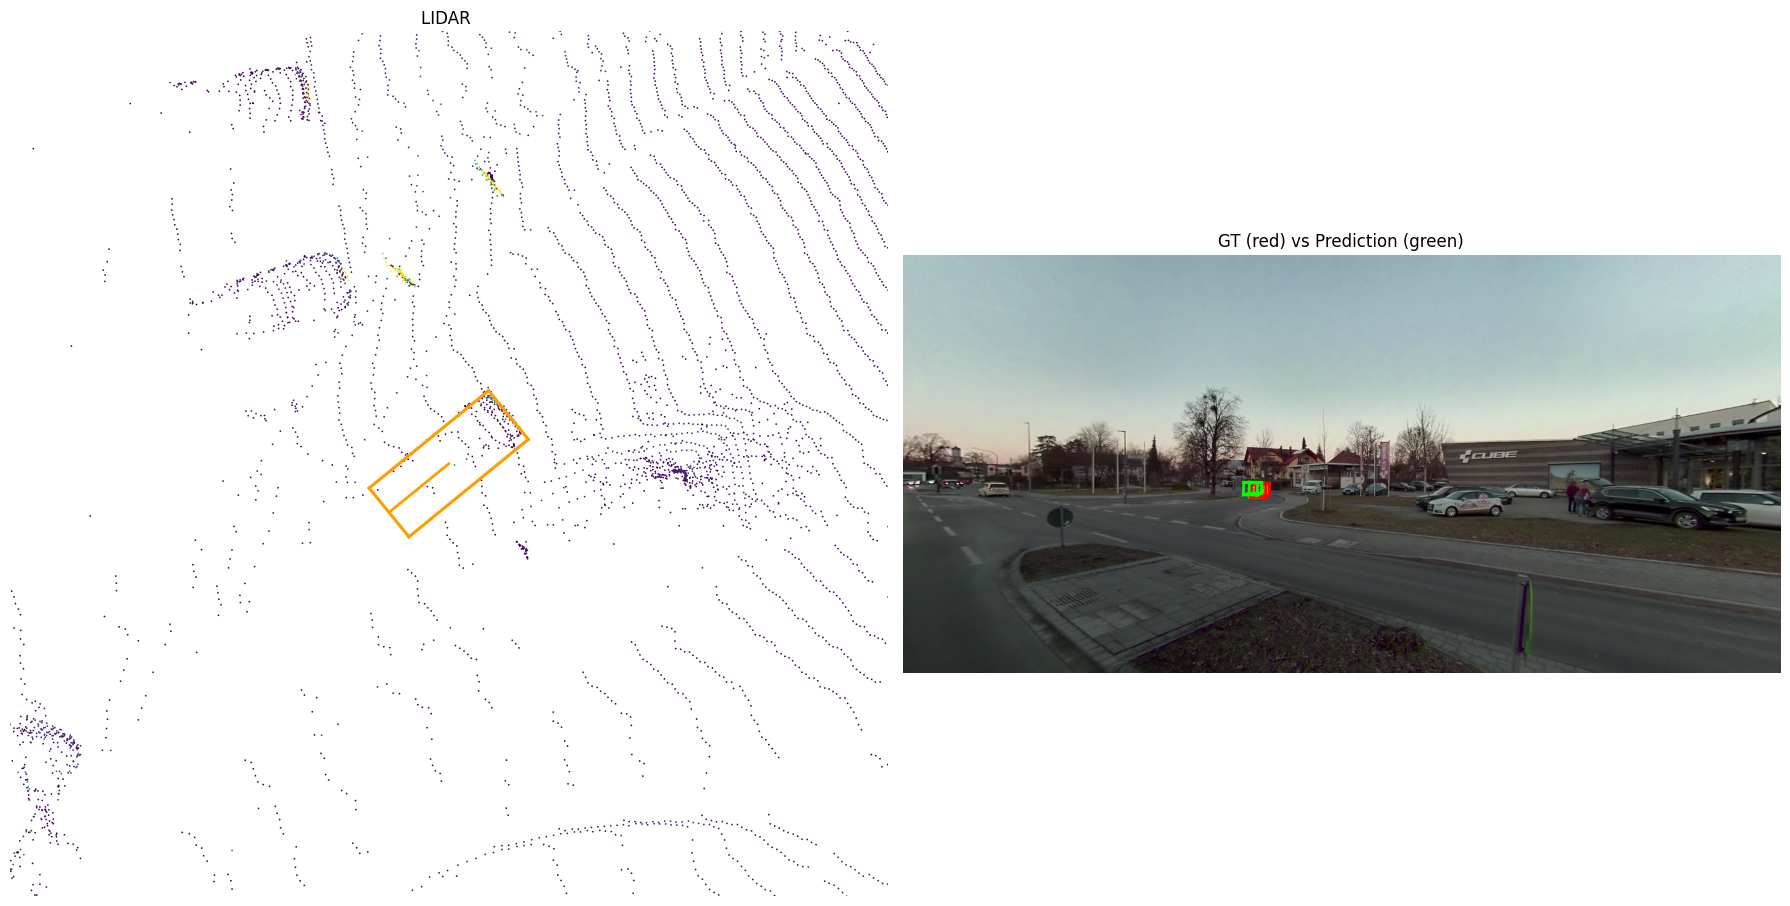

Box GT: label: nan, score: nan, xyz: [-10.99, 0.14, 38.99], wlh: [1.75, 4.29, 1.57], rot axis: [-0.54, 0.59, -0.60], ang(degrees): -126.09, ang(rad): -2.20, vel: nan, nan, nan, name: GT, token: None
Box Prediction: label: nan, score: nan, xyz: [-12.62, 0.02, 41.88], wlh: [1.75, 4.29, 1.57], rot axis: [-0.54, 0.59, -0.60], ang(degrees): -126.09, ang(rad): -2.20, vel: nan, nan, nan, name: Prediction, token: None


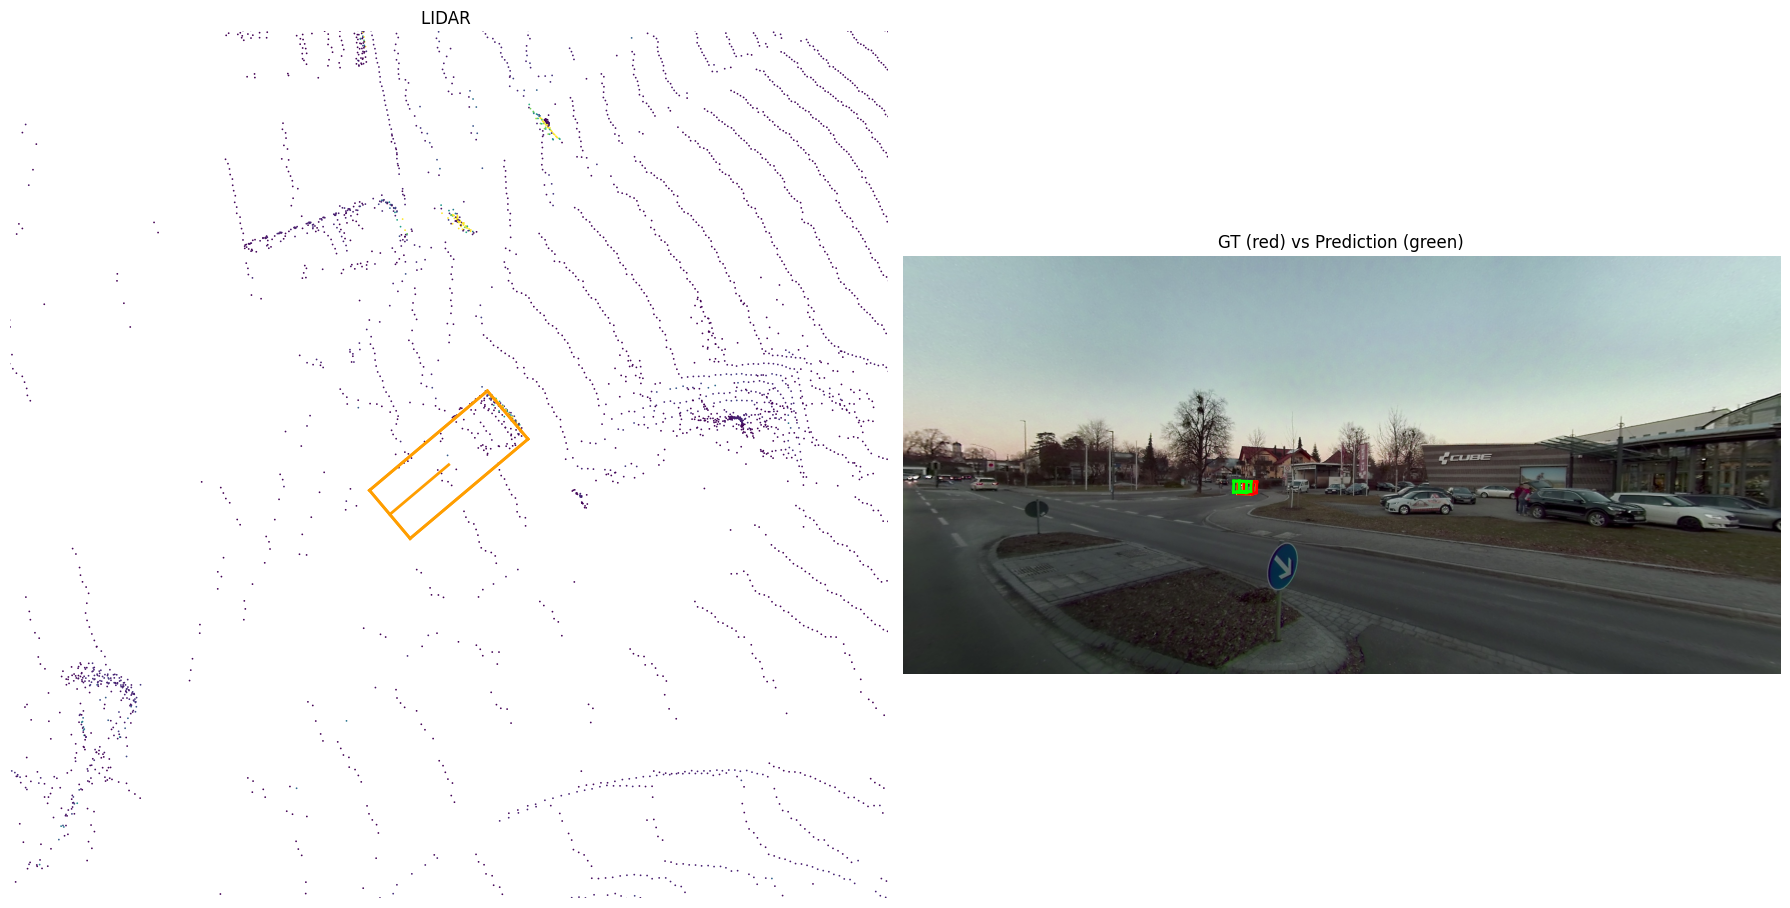

In [93]:
import importlib
import data_visualization
importlib.reload(data_visualization)

from data_visualization import render_box
render_box(trucksc, pred_seq, matched_sample)

Render whole future trajectory

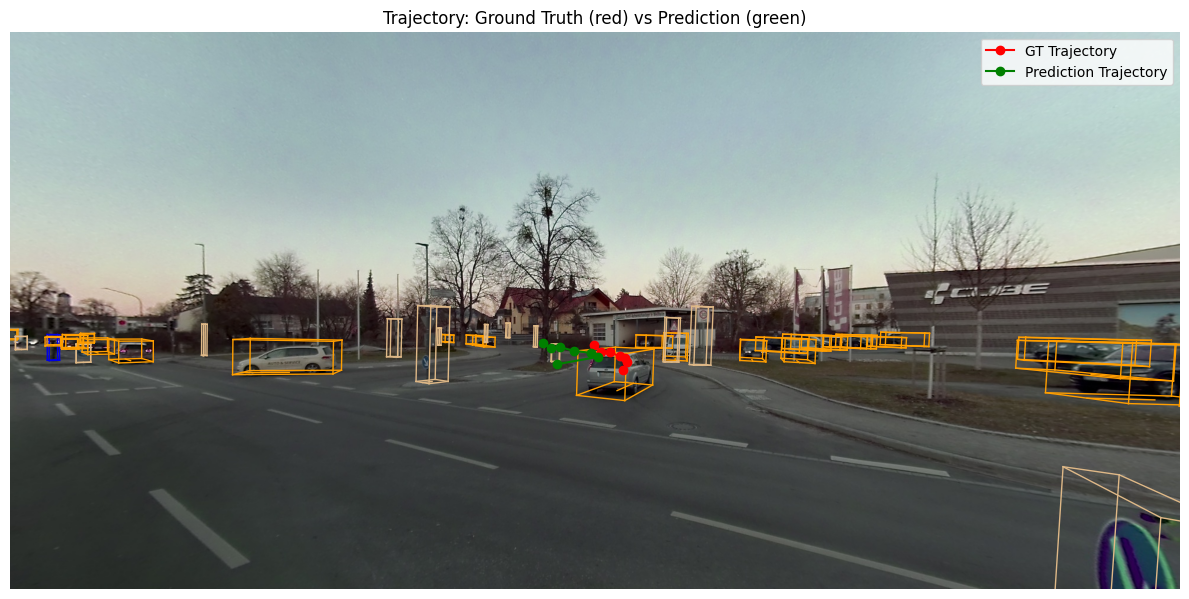

In [45]:
from data_visualization import render_trajectory

render_trajectory(trucksc, matched_sample, pred_seq)